In [1]:
OPENAI_API_KEY=""

# **Conditional Workflow in LangGraph**

## **Project 1:**

### **Smart AI Research Assistant using Conditional Workflow (LangGraph)**

**An intelligent LLM system that dynamically decides whether to answer a query directly or perform real-time web research using query rewriting and search tools for accurate, context-aware responses.**

In [ ]:
#Installing the necessary dependencies
!pip install langchain langchain_openai langgraph pydantic

In [5]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [7]:
from dataclasses import field
class ClassifierSchema(BaseModel):
  query_type : Literal["simple_query", "research_query"] = Field(description='type of the query simple or Research query')

In [9]:
#define State
class ResearchState(TypedDict):
  query: str
  query_type: Literal['simple_query', 'research_query']
  rewritten_query: str
  search_result:str
  final_answer:str

In [8]:
model = ChatOpenAI(model='gpt-4o-mini', api_key=OPENAI_API_KEY)
structured_model = model.with_structured_output(ClassifierSchema)

In [20]:
#check QUERY type
def check_query(state: ResearchState):
  prompt = f'check the type of the query and return simple_query or research_query {state['query']}'
  query_type = structured_model.invoke(prompt).query_type

  return {'query_type': query_type }

In [108]:
#direct llm node

def direct_llm(state:ResearchState):
  prompt = f'give the precise answer to this query: \n {state['query']}'
  response = model.invoke(prompt).content
  return {'final_answer': response}

In [109]:
def rewrite_query(state:ResearchState):
  prompt = f'rewrite the query to make it perfect for web search, query: \n {state['query']}'
  rewritten_query = model.invoke(prompt).content
  return {'rewritten_query': rewritten_query}

In [ ]:
TAVILY_API_KEY = ''

In [111]:
!pip install langchain-tavily

In [112]:
import getpass
import os

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key:\n")

In [113]:
#web search using langchain
from langchain_tavily import TavilySearch

def web_search_node(state: ResearchState):
  tool = TavilySearch(
      max_results=5,
      topic="general",
      )

  query = state['rewritten_query']
  response = tool.invoke({'query': query })
  researched_content = "\n\n".join(result['content'] for result in response['results'])
  return {'search_result': researched_content}

In [114]:
#research llm

def research_node(state:ResearchState):
  prompt = f"""this is research of the topic and give best final answer research
  user based on this research content \n {state['search_result']} \n\n and this
  is query \n {state['rewritten_query']}"""

  response = model.invoke(prompt).content

  return {'final_answer': response}

In [115]:
#decision maker

def route_query(state: ResearchState):

  if state['query_type'] == "simple_query":
    return "direct_llm"
  else:
    return "rewrite_query"

In [116]:
graph = StateGraph(ResearchState)

#add nodes
graph.add_node('classifier', check_query)
graph.add_node('direct_llm', direct_llm)
graph.add_node('rewrite_query', rewrite_query)
graph.add_node('web_search', web_search_node)
graph.add_node('research_node', research_node)


#add edges
graph.add_conditional_edges(
    "classifier",
    route_query,
    {
        "direct_llm":"direct_llm",
        "rewrite_query":"rewrite_query"
    }
)


graph.add_edge('rewrite_query', 'web_search')
graph.add_edge('web_search', 'research_node')
graph.add_edge('research_node', END)
graph.add_edge('direct_llm', END)

graph.set_entry_point('classifier')
workflow = graph.compile()

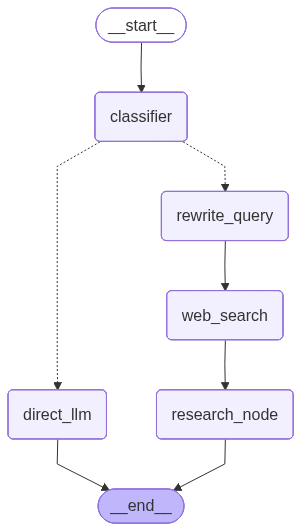

In [117]:
workflow

In [118]:
initial_state = {
    'query': 'hi, how are you'
}

In [119]:
response = workflow.invoke(initial_state)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ClassifierSchema(query_type='simple_query'), input_type=ClassifierSchema])
  return self.__pydantic_serializer__.to_python(


In [120]:
response['query_type']

'simple_query'

In [121]:
response['final_answer']

"Hello! I'm just a program, but I'm here and ready to help you. How can I assist you today?"